In [32]:
import polars as pl
import bz2
import gzip as gz
import matplotlib.pyplot as plt
import numpy as np

In [2]:
df = pl.scan_parquet("/home/ma/a/alb25/Project/python_scripts/eda_and_misc/parquet_output/*")

In [3]:
destinations = df.select('destination_computer').unique().collect()['destination_computer'].to_list()

In [4]:
sources = df.select('source_computer').unique().collect()['source_computer'].to_list()

In [ ]:
len(destinations)

15620

In [7]:
len(sources)

16006

In [93]:
df.head().collect()

time,source_user@domain,destination_user@domain,source_computer,destination_computer,authentication_type,logon_type,authentication_orientation,success/failure
str,str,str,str,str,str,str,str,str
"""1""","""ANONYMOUS LOGON@C586""","""ANONYMOUS LOGON@C586""","""C1250""","""C586""","""NTLM""","""Network""","""LogOn""","""Success"""
"""1""","""ANONYMOUS LOGON@C586""","""ANONYMOUS LOGON@C586""","""C586""","""C586""","""?""","""Network""","""LogOff""","""Success"""
"""1""","""C101$@DOM1""","""C101$@DOM1""","""C988""","""C988""","""?""","""Network""","""LogOff""","""Success"""
"""1""","""C1020$@DOM1""","""SYSTEM@C1020""","""C1020""","""C1020""","""Negotiate""","""Service""","""LogOn""","""Success"""
"""1""","""C1021$@DOM1""","""C1021$@DOM1""","""C1021""","""C625""","""Kerberos""","""Network""","""LogOn""","""Success"""


In [ ]:
source_counts = df.group_by('source_computer').len().sort(by='len', descending=True).collect()
frequencies = source_counts['len'].to_list()

sorted_freqs = np.sort(frequencies)
cdf = np.arange(1, len(sorted_freqs) + 1) / len(sorted_freqs)
plt.figure(figsize=(10, 6))
plt.xscale('log')
plt.xlabel('frequency')
plt.ylabel('prop_of_computers_below_that_frequency')
plt.plot(sorted_freqs, cdf, alpha=0.5)
plt.show()

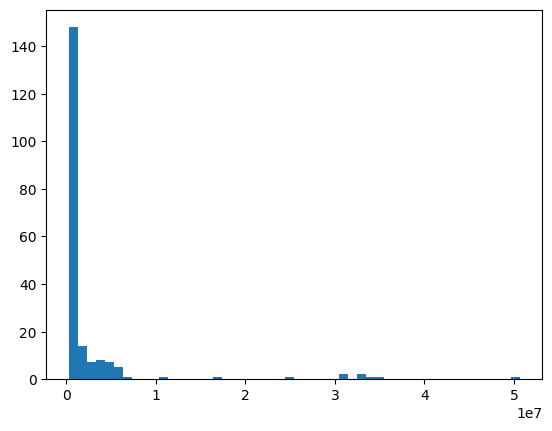

In [80]:
top_pct = source_counts.head(200)
frequencies = top_pct['len'].to_list()
plt.hist(frequencies, bins=50)
plt.show()

In [81]:
source_counts = source_counts.with_columns((pl.col('len').cum_sum() / pl.col('len').sum() *100).alias('cumulative_pct'))
source_counts.head(50)

source_computer,len,cumulative_pct
str,u32,f64
"""C586""",50630165,5.329491
"""C612""",35137579,9.028184
"""C529""",33847062,12.591032
"""C467""",33226389,16.088547
"""C625""",32983300,19.560473
…,…,…
"""C1691""",1502911,45.467105
"""C1183""",1399748,45.614447
"""C2855""",1381941,45.759914


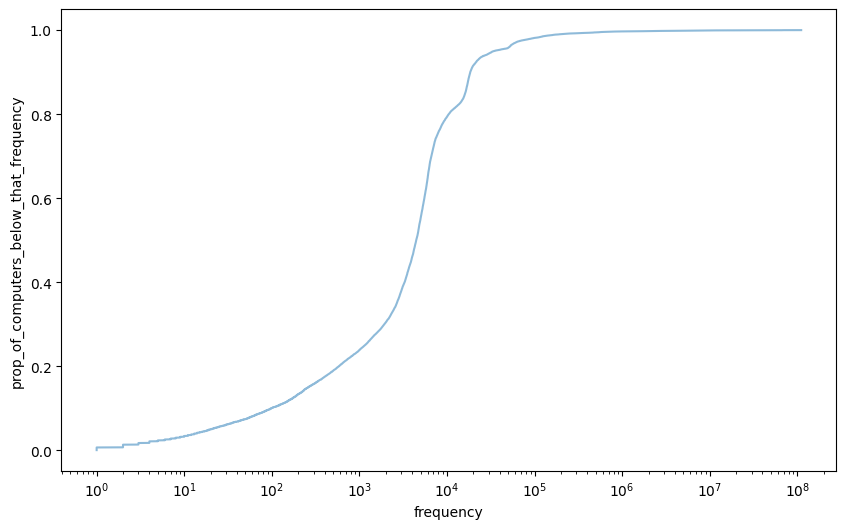

In [82]:
destination_counts = df.group_by('destination_computer').len().sort(by='len', descending=True).collect()
frequencies = destination_counts['len'].to_list()

sorted_freqs = np.sort(frequencies)
cdf = np.arange(1, len(sorted_freqs) + 1) / len(sorted_freqs)
plt.figure(figsize=(10, 6))
plt.xscale('log')
plt.xlabel('frequency')
plt.ylabel('prop_of_computers_below_that_frequency')
plt.plot(sorted_freqs, cdf, alpha=0.5)
plt.show()

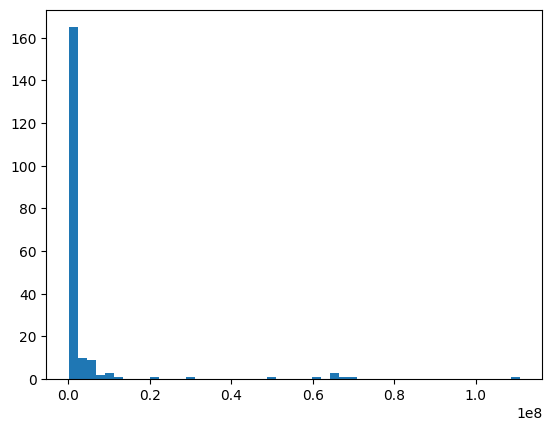

In [83]:
top_pct = destination_counts.head(200)
frequencies = top_pct['len'].to_list()
plt.hist(frequencies, bins=50)
plt.show()

In [84]:
destination_counts = source_counts.with_columns((pl.col('len').cum_sum() / pl.col('len').sum() *100).alias('cumulative_pct'))
destination_counts.head(50)

source_computer,len,cumulative_pct
str,u32,f64
"""C586""",50630165,5.329491
"""C612""",35137579,9.028184
"""C529""",33847062,12.591032
"""C467""",33226389,16.088547
"""C625""",32983300,19.560473
…,…,…
"""C1691""",1502911,45.467105
"""C1183""",1399748,45.614447
"""C2855""",1381941,45.759914


In [ ]:
top_auths = df.group_by('authentication_type').len().collect()
top_auths.sort(by='len', descending=True)

authentication_type,len
str,u32
"""?""",529653766
"""Kerberos""",329665951
"""NTLM""",44959119
"""Negotiate""",44944631
"""MICROSOFT_AUTHENTICATION_PACKA…",675033
…,…
"""CygwinLsa""",14
"""MICROSOFT_AUTHENTICATION_""",5
"""MICROSOFT_AUTHENTICATIO""",4


In [95]:
df.group_by('success/failure').len().collect()

success/failure,len
str,u32
"""Success""",938810236
"""Fail""",11189764
